# 3.5 Complement

The complement of a layout $L : \mathbb{Z}(L) \to D$ is a layout $L^* : \mathbb{Z}(L^*) \to D$ that satisfies the following conditions

**Weak congruence with codomain:**
$$D \lesssim L^* \tag{27}$$

**Disjoint images:**
$$\forall b \in \mathbb{Z}(L),\ \forall a \in \mathbb{Z}_{L^*} / \{0\},\ L(b) \neq L^*(a) \tag{28}$$

**Ordered image:**
$$\forall a \in \mathbb{Z}_{|L^*|} / \{0\},\ L^*(a-1) < L^*(a) \tag{29}$$

The complement of a layout is a layout that generates elements in the codomain of the original layout but not in the image. In composition, a layout $L$ is often used as an indirection into another layout, so the complement $L^*$ is a layout that points to elements omitted by $L$. The complement operation enables the splitting of a layout via logical divide (Section 3.5.2) and enables repetition and extension of a layout via logical product (Section 3.5.1).

In [1]:
from tensor_layouts import Layout, size, cosize, rank, depth, mode, flatten, coalesce
from tensor_layouts import compose, complement, logical_divide, logical_product
from tensor_layouts import zipped_divide, tiled_divide, flat_divide
from tensor_layouts import blocked_product, raked_product
from tensor_layouts.viz import draw_layout, show_layout

In this section, we are only concerned with layouts that have a codomain $D$ that is an HTuple($\mathbb{Z}$): the integers or coordinates with $D = \mathbb{Z}_D$ for some profile $D$. This enables the weak congruence condition Eq. 27. The disjoint images condition, Eq. 28, ensures that the complement generates distinct values from the original layout. Note that the finite domain $\mathbb{Z}(L)$ of the original layout is used, while the infinite extended domain $\mathbb{Z}_{L^*}$ of the complement is used. This provides that whether the complement shape is truncated or extended (e.g. through composition with a layout on the right), it will always generate distinct values. Finally, the ordered image condition, Eq. 29, establishes uniqueness of the complement layout.

### Examples of complements (Table 7)

In [2]:
# Table 7: Examples of layout complements
# When a layout already covers its full codomain (no gaps), the complement
# is trivial: the library returns 1:0, while the paper shows 1:cosize.
# Both satisfy the disjoint images property. The interesting cases are
# layouts with stride gaps, where the complement "fills the holes."

examples = [
    ("(4,8):(1,4)",            Layout((4, 8), (1, 4)),       "No gaps — complement is trivial"),
    ("(4,8):(8,1)",            Layout((4, 8), (8, 1)),       "Order doesn't matter"),
    ("(4,(4,2)):(4,(1,16))",   Layout((4, (4, 2)), (4, (1, 16))), "Hierarchy doesn't matter"),
    ("(4,8):(1,5)",            Layout((4, 8), (1, 5)),       "Non-power-of-2 stride"),
    ("(4,8):(1,8)",            Layout((4, 8), (1, 8)),       "Gaps! complement fills holes"),
]

for name, L, comment in examples:
    Lc = complement(L)
    print(f"L = {name:30s}  =>  L* = {str(Lc):20s}  # {comment}")

L = (4,8):(1,4)                     =>  L* = 1 : 0                 # No gaps — complement is trivial
L = (4,8):(8,1)                     =>  L* = 1 : 0                 # Order doesn't matter
L = (4,(4,2)):(4,(1,16))            =>  L* = 1 : 0                 # Hierarchy doesn't matter
L = (4,8):(1,5)                     =>  L* = 1 : 0                 # Non-power-of-2 stride
L = (4,8):(1,8)                     =>  L* = 2 : 4                 # Gaps! complement fills holes


In [3]:
# Verify the disjoint images property on a concrete example:
# (4,8):(1,8) has gaps — the complement fills them
L = Layout((4, 8), (1, 8))
Lc = complement(L)
print(f"L  = {L}")
print(f"L* = {Lc}")

# L maps to: {0,1,2,3, 8,9,10,11, 16,..., 56,57,58,59} — gaps at 4-7, 12-15, etc.
L_image = {L(i) for i in range(size(L))}
gaps = sorted(set(range(cosize(L))) - L_image)
print(f"\nL covers {len(L_image)} of {cosize(L)} positions in its codomain")
print(f"Gaps (not in L's image): {gaps[:12]} ...")

# The complement 2:4 maps: 0->0, 1->4.
# The disjoint condition (Eq. 28) excludes a=0, so only L*(1)=4
# needs to be outside L's image within the finite domain.
Lc_image_nonzero = {Lc(a) for a in range(1, size(Lc))}
print(f"\nL* non-zero image: {sorted(Lc_image_nonzero)}")
print(f"Disjoint from L: {Lc_image_nonzero.isdisjoint(L_image)}")

L  = (4, 8) : (1, 8)
L* = 2 : 4

L covers 32 of 60 positions in its codomain
Gaps (not in L's image): [4, 5, 6, 7, 12, 13, 14, 15, 20, 21, 22, 23] ...

L* non-zero image: [4]
Disjoint from L: True


L = (4,8):(1,8) — note the gaps between columns


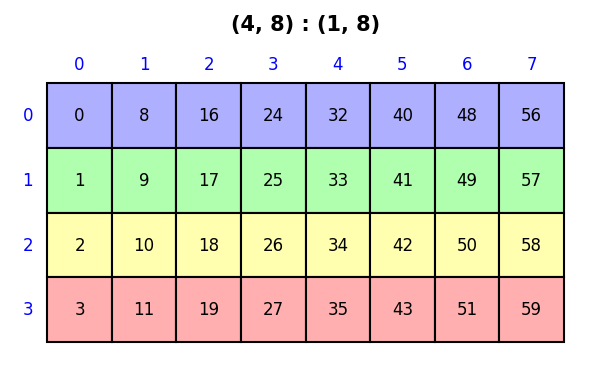


L* = complement — fills the gaps


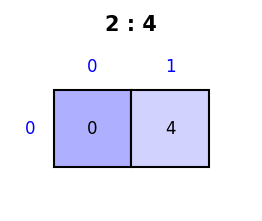

In [4]:
# Visualize: (4,8):(1,8) and its complement (2,1):(4,64)
# The complement fills the stride gaps left by L
print("L = (4,8):(1,8) — note the gaps between columns")
draw_layout(L, colorize=True)

print("\nL* = complement — fills the gaps")
draw_layout(Lc, colorize=True)

## 3.5.1 Application: Logical Product

The logical product of two layouts $A$ and $B$ is a layout $R$ where "each element of layout $B$ has been replaced with a uniquely shifted version of the layout $A$."

Concretely, we define the logical product as a function of two layouts to produce a rank-2 layout

$$A \otimes B = (A, A^* \circ B)$$

where $A^*$ is the complement of $A$. Note that the first mode of the result is exactly the input layout $A$ and the second mode is compatible with the input layout $B$ in shape and order of elements. The first mode, the $A$ layout, is typically referred to as the "tile" which is repeated across the "grid" layout $B$.

Consider the example of a row-major layout $(3, 4) : (4, 1)$ tile to be reproduced in a col-major layout $(2, 5) : (1, 2)$ grid:

$$(3, 4) : (4, 1) \otimes (2, 5) : (1, 2) = \left((3, 4) : (4, 1),\ 1 : 12 \circ (2, 5) : (1, 2)\right) = ((3, 4), (2, 5)) : ((4, 1), (12, 24))$$

where the layout $1 : 12$ is the complement of $(3, 4) : (4, 1)$. In the first mode of the result, the original tile is available and the second mode of the result repeats the original tile uniquely 10 times in a $2 \times 5$ col-major order.

In [5]:
# Logical product: (3,4):(4,1) tile x (2,5):(1,2) grid
A = Layout((3, 4), (4, 1))
B = Layout((2, 5), (1, 2))

print(f"A  = {A}")
print(f"B  = {B}")

# logical_product computes the complement internally with the right bound
R = logical_product(A, B)
print(f"\nA ⊗ B = {R}")

# Verify: first mode is exactly A, second mode encodes the grid
print(f"\nFirst mode (tile):  {mode(R, 0)}")
print(f"Second mode (grid): {mode(R, 1)}")

# The grid mode stride of 12 = cosize(A), confirming the complement is 1:12
print(f"\ncosize(A) = {cosize(A)} — this is the stride used to space out grid copies")

A  = (3, 4) : (4, 1)
B  = (2, 5) : (1, 2)

A ⊗ B = ((3, 4), (2, 5)) : ((4, 1), (12, 24))

First mode (tile):  (3, 4) : (4, 1)
Second mode (grid): (2, 5) : (12, 24)

cosize(A) = 12 — this is the stride used to space out grid copies


Logical product: ((3,4),(2,5)) : ((4,1),(12,24))


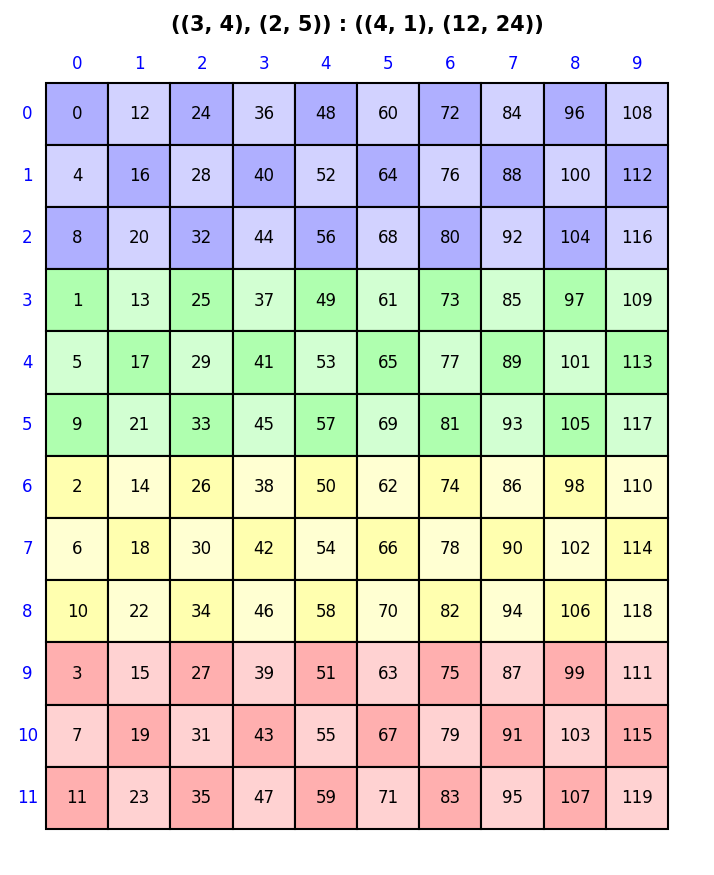

In [6]:
# Visualize the logical product result
print("Logical product: ((3,4),(2,5)) : ((4,1),(12,24))")
draw_layout(R, colorize=True)

As another example, consider layout $(4, 8) : (20, 2)$ tile to be reproduced in a row-major layout $(3, 2) : (2, 1)$ grid:

$$(4, 8) : (20, 2) \otimes (3, 2) : (2, 1) = \left((4, 8) : (20, 2),\ (2, 1) : (1, 80) \circ (3, 2) : (2, 1)\right) = ((4, 8), (3, 2)) : ((20, 2), (80, 1))$$

where the layout $(2, 1) : (1, 80)$ is the complement of $(4, 8) : (20, 2)$. Note that the grid is now interleaving the tiles to produce the smallest codomain of the result. The complement layout tells the result how to stride the layout $B$ and layout $B$ is telling the result how to order and shape the complement layout.

In [7]:
# Logical product: (4,8):(20,2) tile x (3,2):(2,1) grid
A2 = Layout((4, 8), (20, 2))
B2 = Layout((3, 2), (2, 1))

print(f"A  = {A2}")
print(f"B  = {B2}")

R2 = logical_product(A2, B2)
print(f"\nA ⊗ B = {R2}")
print(f"First mode (tile):  {mode(R2, 0)}")
print(f"Second mode (grid): {mode(R2, 1)}")

# Here the complement of (4,8):(20,2) is (2,1):(1,80), which interleaves tiles
print(f"\ncomplement(A) = {complement(A2)}")
print("The grid interleaves tiles to produce the smallest codomain.")

A  = (4, 8) : (20, 2)
B  = (3, 2) : (2, 1)

A ⊗ B = ((4, 8), (3, 2)) : ((20, 2), (80, 1))
First mode (tile):  (4, 8) : (20, 2)
Second mode (grid): (3, 2) : (80, 1)

complement(A) = 2 : 1
The grid interleaves tiles to produce the smallest codomain.


### Related Products

The logical product produces a rank-2 layout, where the first mode is the original tile and the second mode is interpreted as the grid, or "tiling", of that tile.

While the logical product has no restrictions on the rank or compatibility of $A$ and $B$, the operation `blocked_product` is often a more intuitive version which uses the rank of the inputs to construct the shape of the result. We might expect the product of a $3 \times 4$ layout with a $2 \times 5$ layout to produce a $6 \times 20$ layout. The `blocked_product` requires the rank of $A$ and $B$ to be the same, $\text{rank}(A) = \text{rank}(B)$, so that it can apply a zip operation to combine logical row-modes with row-modes and logical col-modes with col-modes. For instance, rearranging the modes of the example above

$$((3, 4), (2, 5)) : ((4, 1), (12, 24)) \Longrightarrow ((3, 2), (4, 5)) : ((4, 12), (1, 24))$$

results in a $6 \times 20$ layout.

blocked_product((3, 4) : (4, 1), (2, 5) : (1, 2))
  = ((3, 2), (4, 5)) : ((4, 12), (1, 24))
  size = 120

blocked_product — each 3x4 tile is a shifted copy of A


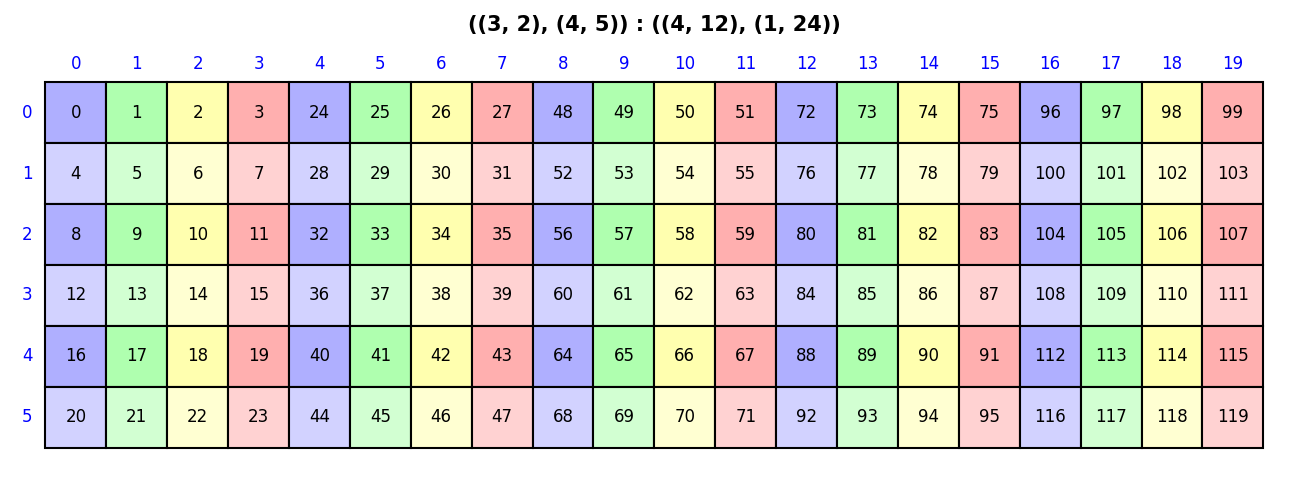

In [8]:
# blocked_product: 3x4 tile blocked over 2x5 grid => 6x20
A = Layout((3, 4), (4, 1))
B = Layout((2, 5), (1, 2))

bp = blocked_product(A, B)
print(f"blocked_product({A}, {B})")
print(f"  = {bp}")
print(f"  size = {size(bp)}")

print("\nblocked_product — each 3x4 tile is a shifted copy of A")
draw_layout(bp, colorize=True)

The operation `raked_product` is similar to the blocked product except the modes are zipped in reverse:

$$((3, 4), (2, 5)) : ((4, 1), (12, 24)) \Longrightarrow ((2, 3), (5, 4)) : ((12, 4), (24, 1))$$

which results in the $3 \times 4$ tile being "raked" over the $2 \times 5$ tile rather than "blocked".

raked_product((3, 4) : (4, 1), (2, 5) : (1, 2))
  = ((2, 3), (5, 4)) : ((12, 4), (24, 1))
  size = 120

raked_product — the 3x4 tile is 'raked' across the grid


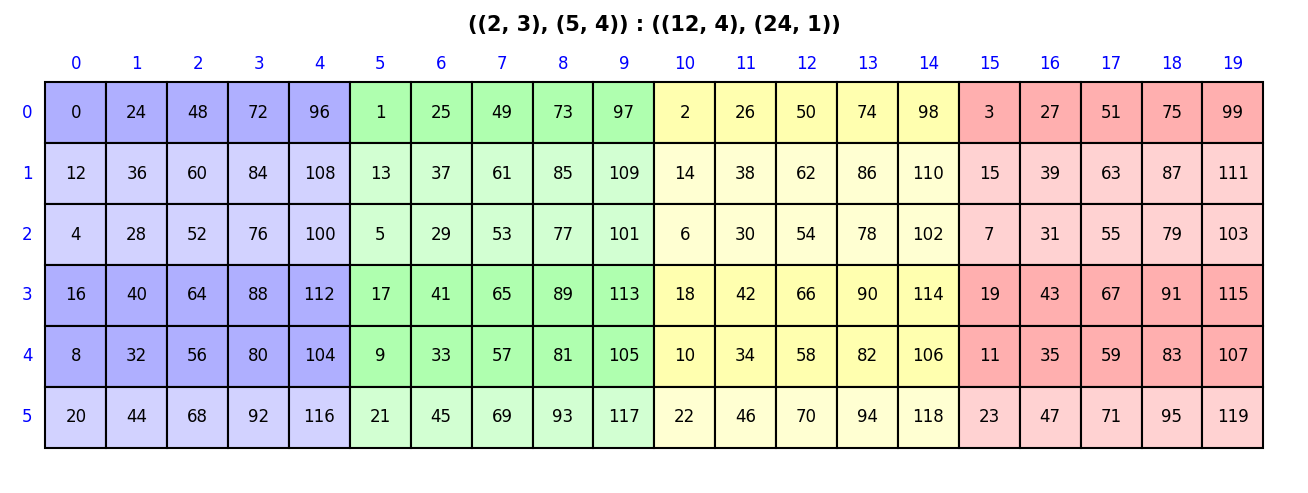

In [9]:
# raked_product: 3x4 tile raked over 2x5 grid => 6x20
rp = raked_product(A, B)
print(f"raked_product({A}, {B})")
print(f"  = {rp}")
print(f"  size = {size(rp)}")

print("\nraked_product — the 3x4 tile is 'raked' across the grid")
draw_layout(rp, colorize=True)

Many other versions of logical product can be produced that additionally group and rearrange modes to produce a convenient result.

## 3.5.2 Application: Logical Divide

The logical division of two layouts $A$ and $B$ is a layout $R$ where "layout $A$ is split into two: the elements that are pointed to by $B$ and those elements that are not pointed to by $B$."

Concretely, we define logical division as a function of two layouts to produce a rank-2 layout

$$A \oslash B = A \circ (B, B^*_{|A|}) = A \circ B^\star$$

where $B^*_{|A|}$ is the complement of $B$ taken with respect to the size of layout $A$. Because this operation intends to preserve all elements of $A$ and simply split layout $A$ into two, we require that $B^\star = (B, B^*_{|A|})$ is surjective onto $\mathbb{Z}_{|A|}$. This often involves an extension of the size of $B^*$ so that $|B^\star| \geq |A|$. Furthermore, we require the complement $B^*$ to "complete" the layout $B$ in the sense that $B^\star = (B, B^*_{|A|})$ has a reflexive generalized inverse $B^+$ which satisfies:

$$B^\star B^+ B^\star = B^\star \tag{30}$$
$$B^+ B^\star B^+ = B^+ \tag{31}$$

In analogy with the logical product operation, the first mode of the result layout $A \circ B$ is typically referred to as the "tile" which is repeated across the "grid", or "tiling", layout $A \circ B^*_{|A|}$. The $B$ argument is referred to as the "tiler", which can be extended beyond simply being a layout as in Section 3.3.5.

As an immediate example, it is common to ask for some set of logical elements from another layout. For example, to extract every third element from a layout we can use composition:

$$\frac{24}{3} \circ \frac{8}{3} = \frac{8}{9}$$

$$\frac{(6,2,2)}{(2,1,20)} \circ \frac{8}{3} = \frac{(2,2,2)}{(6,1,20)}$$

In both cases above, a layout of 24 elements is composed with the layout $8 : 3$, which yields a layout of every third element. But what about the "rest" of the elements from the left-hand side layout? Logical divide splits the left-hand side layout into two pieces: the part that gets "hit" by the right-hand side and the "rest":

$$\frac{24}{3} \oslash \frac{8}{3} = \frac{24}{3} \circ \frac{(8, 3)}{(3, 1)} = \frac{(8, 3)}{(9, 3)}$$

$$\frac{(6,2,2)}{(2,1,20)} \oslash \frac{8}{3} = \frac{(6,2,2)}{(2,1,20)} \circ \frac{(8, 3)}{(3, 1)} = \frac{((2,2,2), 3)}{((6,1,20), 2)}$$

where $3 : 1$ is the complement of $8 : 3$ under the size of 24. The first mode of the result again contains every third element of the left-hand side layout as requested and the second mode of the result is the number of those "tiles" that are contained in the original layout (3 in this case) and the strides between those tiles. The complement is used to determine which elements are missing and in what order to keep them.

In [10]:
# Composition: extract every third element
L1 = Layout(24, 3)
tiler = Layout(8, 3)

comp = compose(L1, tiler)
print(f"compose({L1}, {tiler}) = {comp}")

# Logical divide: split into "hit" and "rest"
div = logical_divide(L1, tiler)
print(f"logical_divide({L1}, {tiler}) = {div}")
print(f"  First mode (tile): {mode(div, 0)}")
print(f"  Second mode (rest): {mode(div, 1)}")

compose(24 : 3, 8 : 3) = 8 : 9
logical_divide(24 : 3, 8 : 3) = (8, 3) : (9, 3)
  First mode (tile): 8 : 9
  Second mode (rest): 3 : 3


In [11]:
# Same with a hierarchical layout
L2 = Layout((6, 2, 2), (2, 1, 20))

comp2 = compose(L2, tiler)
print(f"compose({L2}, {tiler}) = {comp2}")

div2 = logical_divide(L2, tiler)
print(f"logical_divide({L2}, {tiler}) = {div2}")
print(f"  First mode (tile): {mode(div2, 0)}")
print(f"  Second mode (rest): {mode(div2, 1)}")

compose((6, 2, 2) : (2, 1, 20), 8 : 3) = (2, 2, 2) : (6, 1, 20)
logical_divide((6, 2, 2) : (2, 1, 20), 8 : 3) = ((2, 2, 2), 3) : ((6, 1, 20), 2)
  First mode (tile): (2, 2, 2) : (6, 1, 20)
  Second mode (rest): 3 : 2


In [12]:
# Verify: the complement of 8:3 under size 24 is 3:1
tiler_comp = complement(tiler, size(L1))
print(f"complement({tiler}, {size(L1)}) = {tiler_comp}")

# The "completed" tiler (B, B*) is surjective onto Z_24
completed = Layout(tiler, tiler_comp)
print(f"Completed tiler: {completed}")
print(f"  size = {size(completed)}, covers all {size(L1)} elements of L")

# Show that composing L with the completed tiler gives the logical divide result
result = compose(L1, completed)
print(f"\ncompose(L, completed) = {result}")
print(f"logical_divide(L, B)  = {div}")

complement(8 : 3, 24) = 3 : 1
Completed tiler: (8, 3) : (3, 1)
  size = 24, covers all 24 elements of L

compose(L, completed) = (8, 3) : (9, 3)
logical_divide(L, B)  = (8, 3) : (9, 3)


### Related Divides

Similar to composition, it is very common to want to apply logical divide by-mode. The same notation and strategy is used

$$A \oslash \langle B, C \rangle = (A_0, A_1) \oslash \langle B, C \rangle = (A_0 \oslash B,\ A_1 \oslash C).$$

The intuition for this is to be able to perform these operations across columns and rows independently and then potentially rearrange those modes to construct new layouts, similar to the layout products. For example, returning to the tilers in Section 3.3.5, using the same tilers with logical divide rather than composition yields the $2 \times 2$ layout of the $4 \times 8$ sublayouts that the tilers point to.

For instance, given a layout $(8, 16) : (20, 1)$, we would like to extract a "tile" where we want 4 consecutive elements down each column and every other element across each row. The by-mode logical divide produces:

$$(8, 16) : (20, 1) \oslash \langle 4 : 1,\ 8 : 2 \rangle = (8, 16) : (20, 1) \circ \left((4, 2) : (1, 4),\ (8, 2) : (2, 1)\right) = ((4, 2), (8, 2)) : ((20, 80), (2, 1))$$

where the "tile" modes are the first sub-modes and the "rest" modes are the second sub-modes. Note that the resulting layout remains $8 \times 16$ and the elements pointed to by the tiler have been permuted to the first $4 \times 8$ block.

In [13]:
# By-mode logical divide: (8,16):(20,1) / <4:1, 8:2>
# Apply logical_divide to each mode independently
data_layout = Layout((8, 16), (20, 1))
tiler_m = Layout(4, 1)  # 4 consecutive elements in mode 0
tiler_n = Layout(8, 2)  # every other element in mode 1

# By-mode: divide each mode separately, then bundle
d0 = logical_divide(mode(data_layout, 0), tiler_m)
d1 = logical_divide(mode(data_layout, 1), tiler_n)
result = Layout(d0, d1)
print(f"data  = {data_layout}")
print(f"tiler = <{tiler_m}, {tiler_n}>")
print(f"mode 0: {mode(data_layout, 0)} / {tiler_m} = {d0}")
print(f"mode 1: {mode(data_layout, 1)} / {tiler_n} = {d1}")
print(f"logical_divide = {result}")
print(f"  size = {size(result)}")

data  = (8, 16) : (20, 1)
tiler = <4 : 1, 8 : 2>
mode 0: 8 : 20 / 4 : 1 = (4, 2) : (20, 80)
mode 1: 16 : 1 / 8 : 2 = (8, 2) : (2, 1)
logical_divide = ((4, 2), (8, 2)) : ((20, 80), (2, 1))
  size = 128


zipped_divide((8, 16) : (20, 1), (4, 8)) = ((4, 8), (2, 2)) : ((20, 1), (80, 8))
  First mode (tile):  (4, 8) : (20, 1)  — the 4x8 sublayout
  Second mode (rest): (2, 2) : (80, 8)  — the 2x2 grid of tiles

zipped_divide result — tile mode is the composition with the tiler


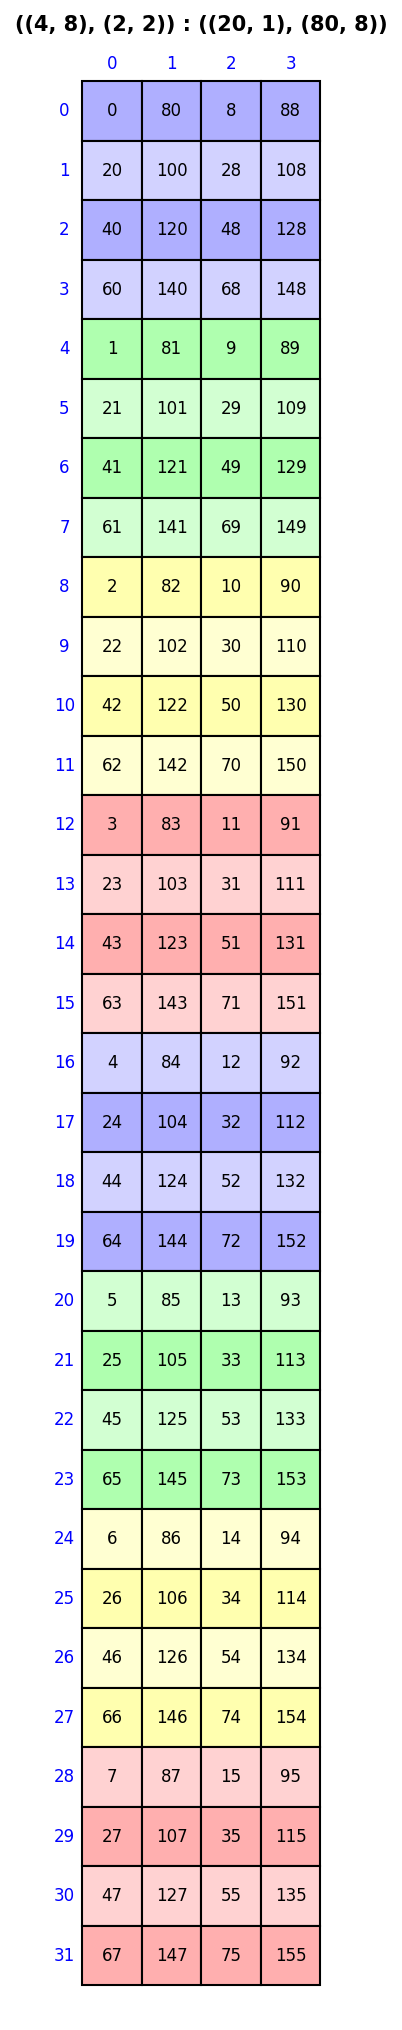

In [14]:
# The operation zipped_divide zips together like-modes.
# For simple shape tilers (no strides), zipped_divide works directly:
data_layout_simple = Layout((8, 16), (20, 1))
zd = zipped_divide(data_layout_simple, (4, 8))
print(f"zipped_divide({data_layout_simple}, (4, 8)) = {zd}")
print(f"  First mode (tile):  {mode(zd, 0)}  — the 4x8 sublayout")
print(f"  Second mode (rest): {mode(zd, 1)}  — the 2x2 grid of tiles")

print("\nzipped_divide result — tile mode is the composition with the tiler")
draw_layout(zd, colorize=True)

A very common pattern in software is tiling a data layout into a grid of tiles and then selecting a particular tile for each processing element. In the PyCuTe implementation, this looks like

```python
data       = Tensor(MyAccessor, MyLayoutMxN)
tiler      = (4, 8)
tiled_data = zipped_divide(data, tiler)
tile       = tiled_data[None, blk_id]       # Slice for a 1D block id
tile       = tiled_data[None, (blk_x, blk_y)] # Slice for a 2D block id
```

As is evident, this pattern is very similar to the thread-value partitioning of Section 3.3.4, but only the tile-mode is actually specified and the missing "Grid" mode is computed as the complement of the tiler. This "completed" tiler with shape (Tile, Grid) is then composed with the data to produce the grid of tiles, which can be sliced in the second mode by a block identifier to extract a particular tile for a processing element.

In [15]:
# Demonstrate the tiling pattern: tile a layout and select blocks
data_layout = Layout((8, 16), (20, 1))
tiler = (4, 8)
tiled = zipped_divide(data_layout, tiler)

print(f"data layout:  {data_layout}")
print(f"tiled layout: {tiled}")
print(f"  Tile mode: {mode(tiled, 0)}")
print(f"  Grid mode: {mode(tiled, 1)}")

# Select individual tiles by slicing in the second mode (grid)
for blk_id in range(size(mode(tiled, 1))):
    tile = tiled(None, blk_id)
    print(f"  Block {blk_id}: tile layout = {tile}")

data layout:  (8, 16) : (20, 1)
tiled layout: ((4, 8), (2, 2)) : ((20, 1), (80, 8))
  Tile mode: (4, 8) : (20, 1)
  Grid mode: (2, 2) : (80, 8)
  Block 0: tile layout = ((4, 8),) : ((20, 1),)
  Block 1: tile layout = ((4, 8),) : ((20, 1),)
  Block 2: tile layout = ((4, 8),) : ((20, 1),)
  Block 3: tile layout = ((4, 8),) : ((20, 1),)


Many other versions of logical divide can be produced that additionally group and rearrange modes to produce a convenient result.